📊 Model Performance:
AUC Score: 0.9999267806935332
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       836
           1       0.99      1.00      0.99       776

    accuracy                           0.99      1612
   macro avg       0.99      0.99      0.99      1612
weighted avg       0.99      0.99      0.99      1612



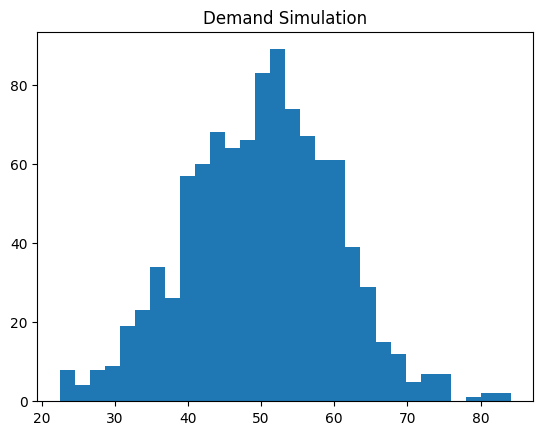

📦 Optimal Order Quantity: 60


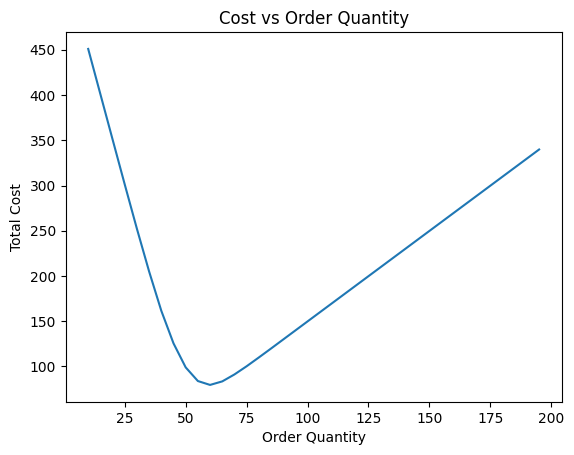


📊 FINAL RESULTS:
Naive Cost: 98.99180051234053
Optimized Cost: 79.61371731134227
Cost Reduction (%): 19.57544271414939

📦 Reorder Point: 286.89512162874655
Safety Stock: 36.89512162874653


In [1]:
# ================================
# 📦 1. IMPORT LIBRARIES
# ================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
from imblearn.over_sampling import SMOTE

np.random.seed(42)

# ================================
# 📊 2. GENERATE SYNTHETIC DATA
# ================================
n = 5000

data = pd.DataFrame({
    'inventory_level': np.random.randint(10, 500, n),
    'lead_time': np.random.randint(1, 10, n),
    'sales_1m': np.random.randint(5, 100, n),
    'sales_3m': np.random.randint(20, 300, n),
    'forecast_3m': np.random.randint(20, 300, n)
})

# Create stockout condition
data['stockout'] = (data['inventory_level'] < data['sales_1m'] * 2).astype(int)

# ================================
# 🤖 3. STOCKOUT PREDICTION (ML)
# ================================
X = data.drop('stockout', axis=1)
y = data['stockout']

# Handle imbalance
smote = SMOTE()
X_res, y_res = smote.fit_resample(X, y)

X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2)

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("📊 Model Performance:")
print("AUC Score:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

# ================================
# 🎲 4. MONTE CARLO SIMULATION
# ================================
def simulate_demand(mean, std, n_sim=1000):
    return np.random.normal(mean, std, n_sim)

# Example SKU
mean_demand = 50
std_demand = 10

simulated_demand = simulate_demand(mean_demand, std_demand)

plt.hist(simulated_demand, bins=30)
plt.title("Demand Simulation")
plt.show()

# ================================
# 📦 5. INVENTORY OPTIMIZATION
# ================================

# Cost parameters
holding_cost = 2
shortage_cost = 10
ordering_cost = 50

def total_cost(Q, demand):
    holding = holding_cost * max(Q - demand, 0)
    shortage = shortage_cost * max(demand - Q, 0)
    return holding + shortage + ordering_cost

# Try different order quantities
Q_values = np.arange(10, 200, 5)
costs = []

for Q in Q_values:
    cost = np.mean([total_cost(Q, d) for d in simulated_demand])
    costs.append(cost)

optimal_Q = Q_values[np.argmin(costs)]

print("📦 Optimal Order Quantity:", optimal_Q)

# Plot cost curve
plt.plot(Q_values, costs)
plt.xlabel("Order Quantity")
plt.ylabel("Total Cost")
plt.title("Cost vs Order Quantity")
plt.show()

# ================================
# 📊 6. FINAL RESULTS
# ================================

# Compare naive vs optimized
naive_Q = 50

naive_cost = np.mean([total_cost(naive_Q, d) for d in simulated_demand])
opt_cost = np.mean([total_cost(optimal_Q, d) for d in simulated_demand])

print("\n📊 FINAL RESULTS:")
print("Naive Cost:", naive_cost)
print("Optimized Cost:", opt_cost)
print("Cost Reduction (%):", ((naive_cost - opt_cost)/naive_cost)*100)

# ================================
# 📈 7. REORDER POINT
# ================================

lead_time = 5
Z = 1.65  # 95% service level

safety_stock = Z * std_demand * np.sqrt(lead_time)
reorder_point = mean_demand * lead_time + safety_stock

print("\n📦 Reorder Point:", reorder_point)
print("Safety Stock:", safety_stock)